In [5]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import tensorflow as tf
tf.config.set_visible_devices([], 'GPU')

import gc, json
import numpy as np
import pandas as pd
from tensorflow.keras import backend as K
from tensorflow.keras.layers import (GlobalAveragePooling2D, Dense, Dropout,
                                      Input, ZeroPadding2D, Resizing, Lambda)
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

# =========================================================
# 1. 백본 및 전처리 함수 임포트
# =========================================================
from tensorflow.keras.applications import (
    EfficientNetB0, EfficientNetB1, EfficientNetB2, EfficientNetB3, EfficientNetB4,
    EfficientNetV2B0, EfficientNetV2B1, EfficientNetV2B2, EfficientNetV2B3, EfficientNetV2S,
    MobileNet, MobileNetV2, MobileNetV3Small, MobileNetV3Large,
    DenseNet121, NASNetMobile,
    ResNet50, ResNet50V2, ResNet101, ResNet101V2,
    Xception, InceptionV3, InceptionResNetV2
)

from tensorflow.keras.applications.mobilenet import preprocess_input as pre_mobilenet
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as pre_mobilenet_v2
from tensorflow.keras.applications.densenet import preprocess_input as pre_densenet
from tensorflow.keras.applications.nasnet import preprocess_input as pre_nasnet
from tensorflow.keras.applications.resnet50 import preprocess_input as pre_resnet50
from tensorflow.keras.applications.resnet_v2 import preprocess_input as pre_resnet_v2
from tensorflow.keras.applications.resnet import preprocess_input as pre_resnet
from tensorflow.keras.applications.xception import preprocess_input as pre_xception
from tensorflow.keras.applications.inception_v3 import preprocess_input as pre_inception_v3
from tensorflow.keras.applications.inception_resnet_v2 import preprocess_input as pre_inception_resnet_v2

# =========================================================
# 2. 모델별 설정: (백본, 해상도, color_mode, Lambda유무, preprocess_fn)
#    노트북 Cell 0~28 각각의 학습 코드와 정확히 일치
# =========================================================
# color_mode: 'gray' = grayscale+Lambda, 'rgb' = rgb 직접
model_configs = {
    # --- grayscale + Lambda, 전처리 없음 ---
    "EfficientNetV2B0":  (EfficientNetV2B0, 224, "gray", None),
    "EfficientNetV2B1":  (EfficientNetV2B1, 240, "gray", None),
    "EfficientNetV2B2":  (EfficientNetV2B2, 260, "gray", None),
    "EfficientNetV2B3":  (EfficientNetV2B3, 300, "gray", None),
    "EfficientNetV2S":   (EfficientNetV2S,  384, "gray", None),
    "EfficientNetB0":    (EfficientNetB0,   224, "gray", None),
    "EfficientNetB1":    (EfficientNetB1,   240, "gray", None),
    "EfficientNetB2":    (EfficientNetB2,   260, "gray", None),
    "EfficientNetB3":    (EfficientNetB3,   300, "gray", None),
    "EfficientNetB4":    (EfficientNetB4,   380, "gray", None),
    "MobileNetV3Small":  (MobileNetV3Small, 224, "gray", None),
    "MobileNetV3Large":  (MobileNetV3Large, 224, "gray", None),
    
    # --- grayscale + Lambda + preprocess_input ---
    "MobileNetV1":       (MobileNet,    224, "gray", pre_mobilenet),
    "MobileNetV2":       (MobileNetV2,  224, "gray", pre_mobilenet_v2),
    "NASNetMobile":      (NASNetMobile, 224, "gray", pre_nasnet),
    "ResNet50V2":        (ResNet50V2,   224, "gray", pre_resnet_v2),
    "ResNet101V2":       (ResNet101V2,  224, "gray", pre_resnet_v2),
    "Xception":          (Xception,     299, "gray", pre_xception),
    "InceptionV3":       (InceptionV3,  299, "gray", pre_inception_v3),
    
    # --- rgb 직접 + preprocess_input (Lambda 없음) ---
    "DenseNet121":       (DenseNet121,       224, "rgb", pre_densenet),
    "ResNet50":          (ResNet50,          224, "rgb", pre_resnet50),
    "ResNet101":         (ResNet101,         224, "rgb", pre_resnet),
    "InceptionResNetV2": (InceptionResNetV2, 299, "rgb", pre_inception_resnet_v2),
}

def build_model(backbone_class, img_size, mode):
    """학습 때와 동일한 아키텍처 재구성"""
    if mode == "gray":
        inputs = Input(shape=(40, 24, 1))
        padded = ZeroPadding2D(padding=((0, 0), (8, 8)))(inputs)
        resized = Resizing(img_size, img_size, interpolation="bicubic")(padded)
        adapted = Lambda(lambda img: tf.image.grayscale_to_rgb(img))(resized)
    else:  # rgb
        inputs = Input(shape=(40, 24, 3))
        padded = ZeroPadding2D(padding=((0, 0), (8, 8)))(inputs)
        resized = Resizing(img_size, img_size, interpolation="bicubic")(padded)
        adapted = resized
    
    base = backbone_class(weights=None, include_top=False, input_shape=(img_size, img_size, 3))
    
    x = base(adapted)
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation="relu")(x)
    x = Dropout(0.4)(x)
    outputs = Dense(1, activation="sigmoid")(x)
    
    return Model(inputs=inputs, outputs=outputs)

# =========================================================
# 3. 데이터 준비
# =========================================================
DEFECTS_PATH = "/Users/gyuminkang/Desktop/solar/InfraredSolarModules"
OUTPUT_PATH  = "/Users/gyuminkang/Desktop/solar/output"

with open(os.path.join(DEFECTS_PATH, 'module_metadata.json'), 'r') as f:
    data = json.load(f)

df = pd.DataFrame.from_dict(data, orient='index')
df['filepath'] = df['image_filepath'].apply(lambda x: os.path.join(DEFECTS_PATH, x))
df['status'] = df['anomaly_class'].apply(lambda x: 'Normal' if x == 'No-Anomaly' else 'Faulty')

_, val_df = train_test_split(df, train_size=0.8, shuffle=True, random_state=42, stratify=df['anomaly_class'])
val_df = val_df.reset_index(drop=True)

# =========================================================
# 4. 모델별 평가
# =========================================================
results = []
total = len(model_configs)
print(f"🚀 총 {total}개의 모델 평가를 시작합니다...\n")

for idx, (model_prefix, (BaseModelClass, img_size, mode, preproc_fn)) in enumerate(model_configs.items(), 1):
    
    K.clear_session()
    gc.collect()
    
    opt_weights = os.path.join(OUTPUT_PATH, f"{model_prefix}_KaggleOptimized_best.weights.h5")
    old_weights = os.path.join(OUTPUT_PATH, f"{model_prefix}_TrueBinary_best.weights.h5")
    
    if os.path.exists(opt_weights):
        weights_path = opt_weights
        version = "Optimized"
    elif os.path.exists(old_weights):
        weights_path = old_weights
        version = "Old Ver"
    else:
        print(f"[{idx}/{total}] ⚠️ {model_prefix} 가중치 파일 없음 — 건너뜀")
        continue
    
    print(f"[{idx}/{total}] 🔄 {model_prefix} ({version}) [해상도:{img_size}, {mode}] ...", end=" ")
    
    try:
        # 모델별 color_mode에 맞는 데이터 제너레이터 생성
        color = 'grayscale' if mode == 'gray' else 'rgb'
        test_datagen = ImageDataGenerator(preprocessing_function=preproc_fn)
        testGen = test_datagen.flow_from_dataframe(
            val_df, x_col='filepath', y_col='status',
            target_size=(40, 24), batch_size=32,
            color_mode=color,
            class_mode='binary', shuffle=False
        )
        
        y_true = testGen.classes
        
        model = build_model(BaseModelClass, img_size, mode)
        model.load_weights(weights_path)
        
        probs = model.predict(testGen, verbose=0)
        y_pred = (probs > 0.5).astype(int).flatten()
        
        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average='weighted')
        
        results.append({
            "Model": model_prefix, "Accuracy": acc, "F1-Score": f1,
            "Resolution": img_size, "Version": version
        })
        print(f"✅ Acc: {acc:.4f} | F1: {f1:.4f}")
        
    except Exception as e:
        print(f"❌ {str(e)[:80]}")
    
    finally:
        try:
            del model, base, testGen, test_datagen
        except:
            pass

# =========================================================
# 5. 최종 리더보드
# =========================================================
K.clear_session()
gc.collect()

if len(results) > 0:
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(by=['Accuracy', 'F1-Score'], ascending=[False, False]).reset_index(drop=True)
    results_df.index += 1
    results_df.index.name = '순위'
    
    print("\n" + "="*70)
    print("🏆 열화상 태양광 패널 모델 최종 리더보드 🏆")
    print("="*70)
    print(results_df.to_string())
    
    csv_path = os.path.join(OUTPUT_PATH, "final_optimized_leaderboard.csv")
    results_df.to_csv(csv_path)
    print(f"\n💾 리더보드 저장: {csv_path}")
else:
    print("\n❌ 평가할 가중치 파일이 없습니다.")

🚀 총 23개의 모델 평가를 시작합니다...

[1/23] 🔄 EfficientNetV2B0 (Optimized) [해상도:224, gray] ... Found 4000 validated image filenames belonging to 2 classes.
✅ Acc: 0.9263 | F1: 0.9261
[2/23] 🔄 EfficientNetV2B1 (Optimized) [해상도:240, gray] ... Found 4000 validated image filenames belonging to 2 classes.
✅ Acc: 0.9243 | F1: 0.9242
[3/23] 🔄 EfficientNetV2B2 (Optimized) [해상도:260, gray] ... Found 4000 validated image filenames belonging to 2 classes.
✅ Acc: 0.9230 | F1: 0.9230
[4/23] 🔄 EfficientNetV2B3 (Optimized) [해상도:300, gray] ... Found 4000 validated image filenames belonging to 2 classes.
✅ Acc: 0.9247 | F1: 0.9246
[5/23] 🔄 EfficientNetV2S (Optimized) [해상도:384, gray] ... Found 4000 validated image filenames belonging to 2 classes.
✅ Acc: 0.9307 | F1: 0.9307
[6/23] 🔄 EfficientNetB0 (Optimized) [해상도:224, gray] ... Found 4000 validated image filenames belonging to 2 classes.
✅ Acc: 0.8205 | F1: 0.8153
[7/23] 🔄 EfficientNetB1 (Optimized) [해상도:240, gray] ... Found 4000 validated image filenames belongin

In [7]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
import tensorflow as tf
tf.config.set_visible_devices([], 'GPU')

import gc, json, time, pickle
import numpy as np
import pandas as pd
from tensorflow.keras import backend as K
from tensorflow.keras.layers import (GlobalAveragePooling2D, Dense, Dropout,
                                      Input, ZeroPadding2D, Resizing, Lambda)
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

from tensorflow.keras.applications import (
    EfficientNetB0, EfficientNetB1, EfficientNetB2, EfficientNetB3, EfficientNetB4,
    EfficientNetV2B0, EfficientNetV2B1, EfficientNetV2B2, EfficientNetV2B3, EfficientNetV2S,
    MobileNet, MobileNetV2, MobileNetV3Small, MobileNetV3Large,
    DenseNet121, NASNetMobile,
    ResNet50, ResNet50V2, ResNet101, ResNet101V2,
    Xception, InceptionV3, InceptionResNetV2
)
from tensorflow.keras.applications.mobilenet import preprocess_input as pre_mobilenet
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as pre_mobilenet_v2
from tensorflow.keras.applications.densenet import preprocess_input as pre_densenet
from tensorflow.keras.applications.nasnet import preprocess_input as pre_nasnet
from tensorflow.keras.applications.resnet50 import preprocess_input as pre_resnet50
from tensorflow.keras.applications.resnet_v2 import preprocess_input as pre_resnet_v2
from tensorflow.keras.applications.resnet import preprocess_input as pre_resnet
from tensorflow.keras.applications.xception import preprocess_input as pre_xception
from tensorflow.keras.applications.inception_v3 import preprocess_input as pre_inception_v3
from tensorflow.keras.applications.inception_resnet_v2 import preprocess_input as pre_inception_resnet_v2

# =========================================================
# 모델별 설정 (학습 때와 정확히 동일)
# =========================================================
model_configs = {
    "EfficientNetV2B0":  (EfficientNetV2B0, 224, "gray", None),
    "EfficientNetV2B1":  (EfficientNetV2B1, 240, "gray", None),
    "EfficientNetV2B2":  (EfficientNetV2B2, 260, "gray", None),
    "EfficientNetV2B3":  (EfficientNetV2B3, 300, "gray", None),
    "EfficientNetV2S":   (EfficientNetV2S,  384, "gray", None),
    "EfficientNetB0":    (EfficientNetB0,   224, "gray", None),
    "EfficientNetB1":    (EfficientNetB1,   240, "gray", None),
    "EfficientNetB2":    (EfficientNetB2,   260, "gray", None),
    "EfficientNetB3":    (EfficientNetB3,   300, "gray", None),
    "EfficientNetB4":    (EfficientNetB4,   380, "gray", None),
    "MobileNetV3Small":  (MobileNetV3Small, 224, "gray", None),
    "MobileNetV3Large":  (MobileNetV3Large, 224, "gray", None),
    "MobileNetV1":       (MobileNet,    224, "gray", pre_mobilenet),
    "MobileNetV2":       (MobileNetV2,  224, "gray", pre_mobilenet_v2),
    "NASNetMobile":      (NASNetMobile, 224, "gray", pre_nasnet),
    "ResNet50V2":        (ResNet50V2,   224, "gray", pre_resnet_v2),
    "ResNet101V2":       (ResNet101V2,  224, "gray", pre_resnet_v2),
    "Xception":          (Xception,     299, "gray", pre_xception),
    "InceptionV3":       (InceptionV3,  299, "gray", pre_inception_v3),
    "DenseNet121":       (DenseNet121,       224, "rgb", pre_densenet),
    "ResNet50":          (ResNet50,          224, "rgb", pre_resnet50),
    "ResNet101":         (ResNet101,         224, "rgb", pre_resnet),
    "InceptionResNetV2": (InceptionResNetV2, 299, "rgb", pre_inception_resnet_v2),
}

DEFECTS_PATH = "/Users/gyuminkang/Desktop/solar/InfraredSolarModules"
OUTPUT_PATH  = "/Users/gyuminkang/Desktop/solar/output"

def build_model(backbone_class, img_size, mode):
    if mode == "gray":
        inputs = Input(shape=(40, 24, 1))
        padded = ZeroPadding2D(padding=((0, 0), (8, 8)))(inputs)
        resized = Resizing(img_size, img_size, interpolation="bicubic")(padded)
        adapted = Lambda(lambda img: tf.image.grayscale_to_rgb(img))(resized)
    else:
        inputs = Input(shape=(40, 24, 3))
        padded = ZeroPadding2D(padding=((0, 0), (8, 8)))(inputs)
        resized = Resizing(img_size, img_size, interpolation="bicubic")(padded)
        adapted = resized
    base = backbone_class(weights=None, include_top=False, input_shape=(img_size, img_size, 3))
    x = base(adapted)
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation="relu")(x)
    x = Dropout(0.4)(x)
    outputs = Dense(1, activation="sigmoid")(x)
    return Model(inputs=inputs, outputs=outputs)

# =========================================================
# 데이터 준비
# =========================================================
with open(os.path.join(DEFECTS_PATH, 'module_metadata.json'), 'r') as f:
    data = json.load(f)
df = pd.DataFrame.from_dict(data, orient='index')
df['filepath'] = df['image_filepath'].apply(lambda x: os.path.join(DEFECTS_PATH, x))
df['status'] = df['anomaly_class'].apply(lambda x: 'Normal' if x == 'No-Anomaly' else 'Faulty')
_, val_df = train_test_split(df, train_size=0.8, shuffle=True, random_state=42, stratify=df['anomaly_class'])
val_df = val_df.reset_index(drop=True)

# =========================================================
# 🔥 PHASE 1: 전체 모델 예측 확률값 캐싱
# =========================================================
all_probs = {}      # model_name -> probability array (4000,)
model_accs = {}     # model_name -> accuracy
model_f1s = {}      # model_name -> f1
y_true = None

total = len(model_configs)
print(f"🚀 {total}개 모델 예측값 캐싱 시작...\n")
start = time.time()

for idx, (name, (BaseClass, img_size, mode, preproc)) in enumerate(model_configs.items(), 1):
    K.clear_session()
    gc.collect()
    
    weights_path = os.path.join(OUTPUT_PATH, f"{name}_KaggleOptimized_best.weights.h5")
    if not os.path.exists(weights_path):
        weights_path = os.path.join(OUTPUT_PATH, f"{name}_TrueBinary_best.weights.h5")
    if not os.path.exists(weights_path):
        print(f"[{idx}/{total}] ⚠️ {name} 건너뜀 (가중치 없음)")
        continue
    
    print(f"[{idx}/{total}] {name} ...", end=" ", flush=True)
    
    try:
        color = 'grayscale' if mode == 'gray' else 'rgb'
        gen = ImageDataGenerator(preprocessing_function=preproc).flow_from_dataframe(
            val_df, x_col='filepath', y_col='status',
            target_size=(40, 24), batch_size=32,
            color_mode=color, class_mode='binary', shuffle=False
        )
        if y_true is None:
            y_true = gen.classes
        
        model = build_model(BaseClass, img_size, mode)
        model.load_weights(weights_path)
        probs = model.predict(gen, verbose=0).flatten()
        
        preds = (probs > 0.5).astype(int)
        acc = accuracy_score(y_true, preds)
        f1 = f1_score(y_true, preds, average='weighted')
        
        all_probs[name] = probs
        model_accs[name] = acc
        model_f1s[name] = f1
        print(f"✅ {acc:.4f}")
        
    except Exception as e:
        print(f"❌ {str(e)[:60]}")

elapsed = time.time() - start
print(f"\n✅ 캐싱 완료! {len(all_probs)}개 모델, {elapsed:.0f}초 소요")

# 💾 디스크에 저장 (나중에 재사용 가능)
cache = {'probs': all_probs, 'accs': model_accs, 'f1s': model_f1s, 'y_true': y_true}
cache_path = os.path.join(OUTPUT_PATH, 'ensemble_cache.pkl')
with open(cache_path, 'wb') as f:
    pickle.dump(cache, f)
print(f"💾 캐시 저장: {cache_path}")

🚀 23개 모델 예측값 캐싱 시작...

[1/23] EfficientNetV2B0 ... Found 4000 validated image filenames belonging to 2 classes.
✅ 0.9263
[2/23] EfficientNetV2B1 ... Found 4000 validated image filenames belonging to 2 classes.
✅ 0.9243
[3/23] EfficientNetV2B2 ... Found 4000 validated image filenames belonging to 2 classes.
✅ 0.9230
[4/23] EfficientNetV2B3 ... Found 4000 validated image filenames belonging to 2 classes.
✅ 0.9247
[5/23] EfficientNetV2S ... Found 4000 validated image filenames belonging to 2 classes.
✅ 0.9307
[6/23] EfficientNetB0 ... Found 4000 validated image filenames belonging to 2 classes.
✅ 0.8205
[7/23] EfficientNetB1 ... Found 4000 validated image filenames belonging to 2 classes.
✅ 0.7840
[8/23] EfficientNetB2 ... Found 4000 validated image filenames belonging to 2 classes.
✅ 0.8183
[9/23] EfficientNetB3 ... Found 4000 validated image filenames belonging to 2 classes.
✅ 0.8720
[10/23] EfficientNetB4 ... Found 4000 validated image filenames belonging to 2 classes.
✅ 0.8590
[11/23]

In [ ]:
import os, pickle, time
import numpy as np
import pandas as pd
from itertools import combinations
from sklearn.metrics import accuracy_score, f1_score
from scipy.stats import rankdata

OUTPUT_PATH = "/Users/gyuminkang/Desktop/solar/output"

# =========================================================
# 캐시 로드
# =========================================================
with open(os.path.join(OUTPUT_PATH, 'ensemble_cache.pkl'), 'rb') as f:
    cache = pickle.load(f)

all_probs = cache['probs']
model_accs = cache['accs']
model_f1s = cache['f1s']
y_true = cache['y_true']
n_samples = len(y_true)
model_names = list(all_probs.keys())
sorted_models = sorted(model_names, key=lambda m: model_accs[m], reverse=True)

# =========================================================
# 사전 계산 (속도 최적화)
# =========================================================
EPS = 1e-7

def _entropy(p):
    p = np.clip(p, EPS, 1 - EPS)
    return -(p * np.log2(p) + (1 - p) * np.log2(1 - p))

pre_ranks_norm = {}   
pre_ranks_raw = {}    
pre_entropy = {}      
pre_confidence = {}   
pre_kl = {}           

for m in model_names:
    p = all_probs[m]
    pre_ranks_norm[m] = rankdata(p) / n_samples
    pre_ranks_raw[m] = rankdata(p)
    h = _entropy(p)
    pre_entropy[m] = h.mean()
    pre_confidence[m] = np.mean(np.abs(p - 0.5))
    pc = np.clip(p, EPS, 1 - EPS)
    pre_kl[m] = (pc * np.log2(2 * pc) + (1 - pc) * np.log2(2 * (1 - pc))).mean()

print(f"✅ {len(model_names)}개 모델 캐시 로드 완료 (전수조사 모드)\n")

# =========================================================
# 🔥 30개 앙상블 기법 정의
# =========================================================
def run_ensemble(combo, mid):
    S = np.array([all_probs[m] for m in combo])
    n = S.shape[0]
    c = np.clip(S, EPS, 1 - EPS)
    wa = np.array([model_accs[m] for m in combo])
    wf = np.array([model_f1s[m] for m in combo])

    if mid == 1:   return ((S > 0.5).astype(int).mean(axis=0) >= 0.5).astype(int)
    if mid == 2:   return (S.mean(axis=0) > 0.5).astype(int)
    if mid == 3:   w = wa / wa.sum(); return (np.average(S, axis=0, weights=w) > 0.5).astype(int)
    if mid == 4:   w = wf / wf.sum(); return (np.average(S, axis=0, weights=w) > 0.5).astype(int)
    if mid == 5:   w = np.exp(-0.3 * np.arange(n)); w /= w.sum(); return (np.average(S, axis=0, weights=w) > 0.5).astype(int)
    if mid == 6:   e = np.exp((wa - wa.max()) * 20); w = e / e.sum(); return (np.average(S, axis=0, weights=w) > 0.5).astype(int)
    if mid == 7:   return (np.exp(np.mean(np.log(c), axis=0)) > 0.5).astype(int)
    if mid == 8:   return (n / np.sum(1.0 / c, axis=0) > 0.5).astype(int)
    if mid == 9:   return (np.median(S, axis=0) > 0.5).astype(int)
    if mid == 10:  return (np.sort(S, axis=0)[1:-1].mean(axis=0) > 0.5).astype(int) if n >= 4 else (S.mean(axis=0) > 0.5).astype(int)
    if mid == 11:  
        if n >= 4:
            s = np.sort(S, axis=0).copy(); s[0]=s[1]; s[-1]=s[-2]
            return (s.mean(axis=0) > 0.5).astype(int)
        return (S.mean(axis=0) > 0.5).astype(int)
    if mid == 12:  return (np.power(np.mean(np.power(c, 0.5), axis=0), 2) > 0.5).astype(int)
    if mid == 13:  return (np.power(np.mean(np.power(c, 2), axis=0), 0.5) > 0.5).astype(int)
    if mid == 14:  return (np.power(np.mean(np.power(c, 3), axis=0), 1/3) > 0.5).astype(int)
    if mid == 15:  return (np.sum(c**2, axis=0) / (np.sum(c, axis=0) + EPS) > 0.5).astype(int)
    if mid == 16:  return (S.max(axis=0) > 0.5).astype(int)
    if mid == 17:  return (S.min(axis=0) > 0.5).astype(int)
    if mid == 18:  return ((S.max(axis=0) + S.min(axis=0)) / 2 > 0.5).astype(int)
    if mid == 19:  
        if n >= 4:
            s = np.sort(S, axis=0)
            q1, q3 = max(1, int(n*0.25)), min(n-1, int(n*0.75)+1)
            return (s[q1:q3].mean(axis=0) > 0.5).astype(int)
        return (S.mean(axis=0) > 0.5).astype(int)
    if mid == 20:  R = np.array([pre_ranks_norm[m] for m in combo]); return (R.mean(axis=0) > 0.5).astype(int)
    if mid == 21:  R = np.array([pre_ranks_norm[m] for m in combo]); w = wa / wa.sum(); return (np.average(R, axis=0, weights=w) > 0.5).astype(int)
    if mid == 22:  R = np.array([pre_ranks_raw[m] for m in combo]); rrf = np.sum(1.0 / (60 + R), axis=0); rrf_n = (rrf - rrf.min()) / (rrf.max() - rrf.min() + EPS); return (rrf_n > 0.5).astype(int)
    if mid == 23:  ent = np.array([pre_entropy[m] for m in combo]); w = 1.0 / (ent + EPS); w /= w.sum(); return (np.average(S, axis=0, weights=w) > 0.5).astype(int)
    if mid == 24:  ent = np.array([pre_entropy[m] for m in combo]); w = (1.0 - ent) + EPS; w /= w.sum(); return (np.average(S, axis=0, weights=w) > 0.5).astype(int)
    if mid == 25:  kl = np.array([pre_kl[m] for m in combo]); w = kl + EPS; w /= w.sum(); return (np.average(S, axis=0, weights=w) > 0.5).astype(int)
    if mid == 26:  logits = np.log(c / (1 - c)); return (logits.mean(axis=0) > 0).astype(int)
    if mid == 27:  conf = np.array([pre_confidence[m] for m in combo]); w = conf + EPS; w /= w.sum(); return (np.average(S, axis=0, weights=w) > 0.5).astype(int)
    if mid == 28:  prod_p = np.prod(c, axis=0); prod_1mp = np.prod(1 - c, axis=0); return (prod_p / (prod_p + prod_1mp + EPS) > 0.5).astype(int)
    if mid == 29:  w = wa ** 10; w /= w.sum(); return (np.average(S, axis=0, weights=w) > 0.5).astype(int)
    if mid == 30:  w = 1.0 / (1.0 - wa + EPS); w /= w.sum(); return (np.average(S, axis=0, weights=w) > 0.5).astype(int)

METHOD_NAMES = {
    1:"다수결투표", 2:"확률평균", 3:"정확도가중", 4:"F1가중", 5:"지수순위가중", 6:"Softmax가중",
    7:"기하평균", 8:"조화평균", 9:"중앙값", 10:"절사평균", 11:"윈저화평균", 12:"Power(p=0.5)",
    13:"Power(p=2)", 14:"Power(p=3)", 15:"Lehmer(p=2)", 16:"최대확률", 17:"최소확률", 18:"최대최소평균",
    19:"IQR평균", 20:"순위평균", 21:"가중순위평균", 22:"RRF(k=60)", 23:"Shannon엔트로피", 24:"Negentropy",
    25:"KL발산가중", 26:"Logit평균", 27:"신뢰도가중", 28:"곱규칙", 29:"Sharp가중", 30:"역오차가중"
}

# =========================================================
# 🔥 전수조사 앙상블 조합 탐색
# =========================================================
MAX_N = len(model_names) # 가지고 있는 모든 모델 갯수 (23개)

all_results = []
size_best = {}
total_start = time.time()

print(f"🔥 앙상블 탐색 전수조사 시작: 2~{MAX_N}개 조합 × 30개 기법")
print("⚠️ 주의: 연산량이 매우 많아 조합 수가 큰 구간에서는 시간이 오래 걸릴 수 있습니다.\n")

for n_combo in range(2, MAX_N + 1):
    # 상위 N개 제한 없이 가지고 있는 모든 모델(sorted_models)을 조합의 풀(pool)로 사용
    pool = sorted_models 
    combos = list(combinations(pool, n_combo))
    total_evals = len(combos) * 30

    print(f"📊 탐색 중: {n_combo}개 조합 (총 {total_evals:,}회 연산)...", end=" ", flush=True)
    t0 = time.time()

    best = {"acc": 0}

    for combo in combos:
        for mid in range(1, 31):
            try:
                y_pred = run_ensemble(combo, mid)
                acc = accuracy_score(y_true, y_pred)
                
                # 모든 결과를 메모리에 올리면 터질 수 있으므로, 해당 조합수(n)의 최고 기록만 저장/갱신
                if acc > best["acc"]:
                    f1 = f1_score(y_true, y_pred, average='weighted')
                    best = {"acc": acc, "f1": f1, "method": METHOD_NAMES[mid], "combo": combo}
            except:
                pass

    dt = time.time() - t0
    size_best[n_combo] = best
    
    # 해당 크기의 조합 탐색이 끝날 때마다 결과 기록
    all_results.append({
        "조합수": n_combo,
        "기법": best['method'],
        "Accuracy": best['acc'],
        "F1-Score": best['f1'],
        "모델조합": " + ".join(best['combo'])
    })
    
    print(f"✅ 완료 ({dt:.1f}초)")
    print(f"   ▶ {n_combo}개 앙상블 최고 성능 (Acc: {best['acc']:.4f} / F1: {best['f1']:.4f})")
    print(f"   ▶ 사용된 최적 기법: {best['method']}")
    print(f"   ▶ 조합된 모델 리스트: {', '.join(best['combo'])}\n")

total_elapsed = time.time() - total_start
print(f"⏱️ 전체 전수조사 탐색 완료: {total_elapsed / 60:.1f}분 소요\n")

# =========================================================
# 🏆 최종 결과 정리 및 리더보드 출력
# =========================================================
results_df = pd.DataFrame(all_results)

print(f"\n{'=' * 95}")
print("🏆🏆🏆 조합 크기별(2~N) 최고 앙상블 리더보드 🏆🏆🏆")
print("=" * 95)

# 전수조사이므로 각 크기(n)별로 가장 성능이 높았던 1개씩만 모아서 전체 리더보드를 구성합니다.
top_all = results_df.sort_values(["Accuracy", "F1-Score"], ascending=[False, False]).reset_index(drop=True)
top_all.index += 1
top_all.index.name = "전체순위"

pd.set_option('display.max_colwidth', None)
print(top_all[["조합수", "기법", "Accuracy", "F1-Score", "모델조합"]].to_string())
pd.reset_option('display.max_colwidth')

# 💾 저장
csv_path = os.path.join(OUTPUT_PATH, "ensemble_bruteforce_top_by_size.csv")
top_all.to_csv(csv_path)
print(f"\n💾 리더보드 저장 완료: {csv_path}")

✅ 23개 모델 캐시 로드 완료 (전수조사 모드)

🔥 앙상블 탐색 전수조사 시작: 2~23개 조합 × 30개 기법
⚠️ 주의: 연산량이 매우 많아 조합 수가 큰 구간에서는 시간이 오래 걸릴 수 있습니다.

📊 탐색 중: 2개 조합 (총 7,590회 연산)... ✅ 완료 (2.8초)
   ▶ 2개 앙상블 최고 성능 (Acc: 0.9560 / F1: 0.9560)
   ▶ 사용된 최적 기법: Softmax가중
   ▶ 조합된 모델 리스트: Xception, MobileNetV3Large

📊 탐색 중: 3개 조합 (총 53,130회 연산)... ✅ 완료 (20.0초)
   ▶ 3개 앙상블 최고 성능 (Acc: 0.9593 / F1: 0.9592)
   ▶ 사용된 최적 기법: Power(p=0.5)
   ▶ 조합된 모델 리스트: ResNet101V2, ResNet101, MobileNetV3Large

📊 탐색 중: 4개 조합 (총 265,650회 연산)... ✅ 완료 (106.2초)
   ▶ 4개 앙상블 최고 성능 (Acc: 0.9615 / F1: 0.9615)
   ▶ 사용된 최적 기법: 기하평균
   ▶ 조합된 모델 리스트: ResNet101V2, ResNet101, Xception, MobileNetV3Small

📊 탐색 중: 5개 조합 (총 1,009,470회 연산)... ✅ 완료 (414.8초)
   ▶ 5개 앙상블 최고 성능 (Acc: 0.9617 / F1: 0.9617)
   ▶ 사용된 최적 기법: 기하평균
   ▶ 조합된 모델 리스트: ResNet101V2, ResNet101, Xception, MobileNetV3Small, DenseNet121

📊 탐색 중: 6개 조합 (총 3,028,410회 연산)... ✅ 완료 (1271.1초)
   ▶ 6개 앙상블 최고 성능 (Acc: 0.9617 / F1: 0.9617)
   ▶ 사용된 최적 기법: 기하평균
   ▶ 조합된 모델 리스트: ResNet101V2, ResNet101, Xception, M

Ensemble: ResNet101V2 + ResNet101 + Xception + MobileNetV3Small + DenseNet121
Method: Geometric Mean
Baseline (threshold=0.50): Acc=0.9617 | F1=0.9617

  THRESHOLD FINE-TUNING RESULTS
  Best by Accuracy:  threshold=0.54  |  Acc=0.9620  |  F1=0.9620
  Best by F1-Score:  threshold=0.54  |  Acc=0.9620  |  F1=0.9620
  Baseline (0.50):   threshold=0.50  |  Acc=0.9617  |  F1=0.9617

  Accuracy Gain:  +0.0002 (0.02%p)
  F1-Score Gain:  +0.0003 (0.03%p)

Plot saved: /Users/gyuminkang/Desktop/solar/output/threshold_finetuning.png


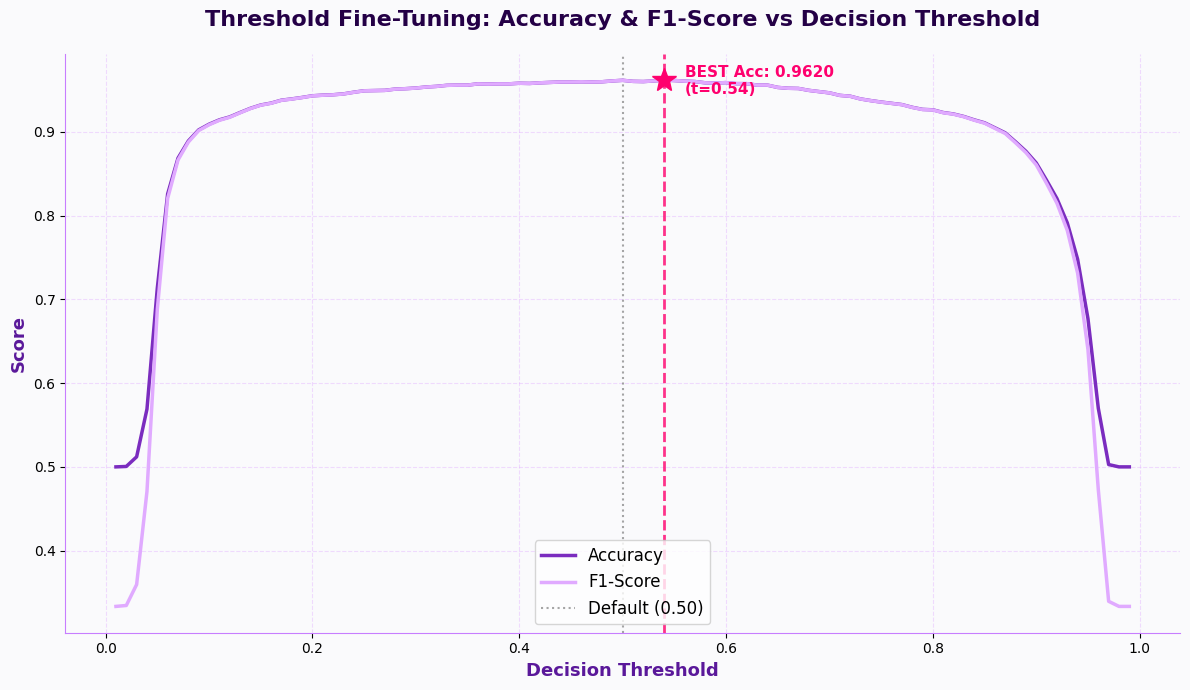

CSV saved: /Users/gyuminkang/Desktop/solar/output/threshold_finetuning_top20.csv

Top 20 Thresholds by Accuracy:

      Threshold  Accuracy  F1-Score  Precision   Recall
Rank                                                   
1          0.54   0.96200  0.962000   0.962017  0.96200
2          0.50   0.96175  0.961747   0.961908  0.96175
3          0.55   0.96150  0.961500   0.961507  0.96150
4          0.53   0.96100  0.960999   0.961056  0.96100
5          0.49   0.96100  0.960996   0.961203  0.96100
6          0.56   0.96075  0.960750   0.960750  0.96075
7          0.51   0.96050  0.960498   0.960604  0.96050
8          0.52   0.96025  0.960248   0.960334  0.96025
9          0.57   0.96025  0.960250   0.960250  0.96025
10         0.48   0.96000  0.959995   0.960243  0.96000
11         0.46   0.96000  0.959993   0.960336  0.96000
12         0.47   0.95975  0.959744   0.960026  0.95975
13         0.45   0.95975  0.959742   0.960124  0.95975
14         0.44   0.95975  0.959741   0.960150

In [1]:
import os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

OUTPUT_PATH = "/Users/gyuminkang/Desktop/solar/output"

# 1. Load cached data
with open(os.path.join(OUTPUT_PATH, 'ensemble_cache.pkl'), 'rb') as f:
    cache = pickle.load(f)

probs = cache['probs']
y_true = np.array(cache['y_true'])
EPS = 1e-7

# =========================================================
# 2. Best Ensemble Configuration (from brute-force search)
# =========================================================
best_models = ['ResNet101V2', 'ResNet101', 'Xception', 'MobileNetV3Small', 'DenseNet121']
method_name = "Geometric Mean"

# Calculate Geometric Mean ensemble probability
S = np.array([probs[m] for m in best_models])
c = np.clip(S, EPS, 1 - EPS)
ensemble_prob = np.exp(np.mean(np.log(c), axis=0))

# Baseline (threshold = 0.5)
baseline_acc = accuracy_score(y_true, (ensemble_prob > 0.5).astype(int))
baseline_f1 = f1_score(y_true, (ensemble_prob > 0.5).astype(int), average='weighted')
print(f"Ensemble: {' + '.join(best_models)}")
print(f"Method: {method_name}")
print(f"Baseline (threshold=0.50): Acc={baseline_acc:.4f} | F1={baseline_f1:.4f}")
print("="*70)

# =========================================================
# 3. Threshold Fine-Tuning (0.01 ~ 0.99, step=0.01)
# =========================================================
thresholds = np.arange(0.01, 1.00, 0.01)
results = []

for t in thresholds:
    y_pred = (ensemble_prob > t).astype(int)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    results.append({
        "Threshold": round(t, 2),
        "Accuracy": acc,
        "F1-Score": f1,
        "Precision": prec,
        "Recall": rec
    })

df_results = pd.DataFrame(results)

# =========================================================
# 4. Find Optimal Thresholds
# =========================================================
best_acc_row = df_results.loc[df_results['Accuracy'].idxmax()]
best_f1_row = df_results.loc[df_results['F1-Score'].idxmax()]

print(f"\n{'='*70}")
print(f"  THRESHOLD FINE-TUNING RESULTS")
print(f"{'='*70}")
print(f"  Best by Accuracy:  threshold={best_acc_row['Threshold']:.2f}  |  Acc={best_acc_row['Accuracy']:.4f}  |  F1={best_acc_row['F1-Score']:.4f}")
print(f"  Best by F1-Score:  threshold={best_f1_row['Threshold']:.2f}  |  Acc={best_f1_row['Accuracy']:.4f}  |  F1={best_f1_row['F1-Score']:.4f}")
print(f"  Baseline (0.50):   threshold=0.50  |  Acc={baseline_acc:.4f}  |  F1={baseline_f1:.4f}")

acc_gain = best_acc_row['Accuracy'] - baseline_acc
f1_gain = best_f1_row['F1-Score'] - baseline_f1
print(f"\n  Accuracy Gain:  +{acc_gain:.4f} ({acc_gain*100:.2f}%p)")
print(f"  F1-Score Gain:  +{f1_gain:.4f} ({f1_gain*100:.2f}%p)")
print(f"{'='*70}\n")

# =========================================================
# 5. Visualization (Purple Theme)
# =========================================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(12, 7), facecolor='#FAFAFC')
ax.set_facecolor('#FAFAFC')

# Plot Accuracy and F1
ax.plot(df_results['Threshold'], df_results['Accuracy'], color='#7B2CBF', linewidth=2.5, label='Accuracy', zorder=3)
ax.plot(df_results['Threshold'], df_results['F1-Score'], color='#E0AAFF', linewidth=2.5, label='F1-Score', zorder=3)

# Mark baseline threshold (0.5)
ax.axvline(0.5, color='gray', linestyle=':', linewidth=1.5, alpha=0.7, label='Default (0.50)')

# Mark best accuracy threshold
ax.axvline(best_acc_row['Threshold'], color='#FF006E', linestyle='--', linewidth=2, alpha=0.8)
ax.plot(best_acc_row['Threshold'], best_acc_row['Accuracy'], marker='*', color='#FF006E', markersize=18, zorder=5)
ax.annotate(f"BEST Acc: {best_acc_row['Accuracy']:.4f}\n(t={best_acc_row['Threshold']:.2f})",
            (best_acc_row['Threshold'], best_acc_row['Accuracy']),
            textcoords="offset points", xytext=(15, -10), fontsize=11, fontweight='bold',
            color='#FF006E', zorder=5)

# Title and labels
ax.set_title("Threshold Fine-Tuning: Accuracy & F1-Score vs Decision Threshold",
             fontsize=16, fontweight='bold', color='#240046', pad=20)
ax.set_xlabel("Decision Threshold", fontsize=13, fontweight='bold', color='#5A189A')
ax.set_ylabel("Score", fontsize=13, fontweight='bold', color='#5A189A')
ax.legend(fontsize=12, loc='lower center')

ax.grid(True, linestyle='--', color='#E0AAFF', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#C77DFF')
ax.spines['bottom'].set_color('#C77DFF')

plt.tight_layout()
PLOT_PATH = os.path.join(OUTPUT_PATH, "threshold_finetuning.png")
plt.savefig(PLOT_PATH, dpi=300, facecolor=fig.get_facecolor())
print(f"Plot saved: {PLOT_PATH}")
plt.show()

# =========================================================
# 6. Save Top-20 Thresholds to CSV
# =========================================================
top20 = df_results.sort_values('Accuracy', ascending=False).head(20).reset_index(drop=True)
top20.index += 1
top20.index.name = "Rank"
csv_path = os.path.join(OUTPUT_PATH, "threshold_finetuning_top20.csv")
top20.to_csv(csv_path)
print(f"CSV saved: {csv_path}")
print(f"\nTop 20 Thresholds by Accuracy:\n")
print(top20.to_string())